# A0b production-universe comparison

This is a variant of `07-stable-profit-validation.ipynb`.

The experiment compares the independent forward-filled simulator (A0), the same simulator restricted to the current production-style Hyperliquid vault universe (A0b), and the production candidate. A0b changes only the candidate universe and the documented data-quality blacklist; it does not import the production engine's stateful execution or sizing code. That keeps it useful as an independent data and accounting check.

Two windows are reported:

* the recorded production candidate period, 2026-01-01 through 2026-07-08 inclusive;
* the full completed backfilled research period, 2025-09-13 through 2026-09-12 inclusive.

The archived production report retained headline metrics but not its daily equity series. The notebook therefore plots the two independent daily curves and marks the archived production endpoint; it does not invent a production curve. A current-source production-engine replay is included in the metrics table where an existing verification run recorded it.


## Key new insights

A0b materially closes the production-period gap by changing the universe only. It finishes at $185,368 (23.58% cumulative return, 50.84% CAGR, 2.43 Sharpe and -7.36% maximum drawdown), versus A0 at $161,482 (7.65%, 15.40%, 0.76 and -15.44%). The current-source production replay finished at $190,095 with 2.87 daily Sharpe and -3.91% drawdown, so A0b is 2.49% below that endpoint and has the same broad return/stability ordering. The archived production endpoint is $191,446; its daily path was not retained.

Over the full backfilled period A0b also improves the independent result: $173,708 final equity, 15.81% cumulative return, 15.85% CAGR, 0.92 Sharpe and -8.59% drawdown, compared with A0's $157,402, 4.93%, 4.95%, 0.34 and -15.64%. A production full-history row is intentionally unavailable because the matching old engine input and equity series were not retained.

## Summary of results

| window | candidate | final equity | CAGR | volatility | Sharpe | max drawdown | curve |
| --- | --- | ---: | ---: | ---: | ---: | ---: | --- |
| 2026-01-01 to 2026-07-08 | A0 | $161,482 | 15.40% | 21.86% | 0.76 | -15.44% | saved |
| 2026-01-01 to 2026-07-08 | A0b | $185,368 | 50.84% | 17.58% | 2.43 | -7.36% | saved |
| 2026-01-01 to 2026-07-08 | production replay | $190,095 | 58.70% | n/a | 2.87 | -3.91% | endpoint only |
| 2025-09-13 to 2026-09-12 | A0 | $157,402 | 4.95% | 20.04% | 0.34 | -15.64% | saved |
| 2025-09-13 to 2026-09-12 | A0b | $173,708 | 15.85% | 17.74% | 0.92 | -8.59% | saved |

The membership table contains 532 addresses: 309 are in the A0 panel but never selected, 194 are outside the current production-style allowlist, one is the manual blacklist entry, and 28 are selected by A0b in the production period. A0 selected 33 addresses. A0b's largest target-dollar contributor accounts for 16.5% of target dollars and its top five account for 62.0%; this is diversified enough to explain the result as a universe effect, while still requiring monitoring.

## Robustness of results

A0b is a diagnostic, not a production recommendation. The allowlist snapshot was generated on 2026-09-09 and applied retrospectively, so it is not a point-in-time historical universe. The simulator remains independent and forward-filled, but it does not reproduce engine-level `can_deposit`, redemption accounting, internal pair identifiers or stateful execution. The production period therefore demonstrates closeness, not exact parity. The recorded production curve is missing, and the full-history production replay cannot be reconstructed from the retained inputs. Results should be treated as a universe-reconciliation finding and validated with a new contemporaneous engine replay before any deployment decision.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd() / "scratchpad/hyperliquid-ic" if (Path.cwd() / "scratchpad/hyperliquid-ic").exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
REWRITE = PROJECT_DIR / "_artifacts-rewrite"
ARTIFACTS = PROJECT_DIR / "_artifacts-a0b"
ARTIFACTS.mkdir(exist_ok=True)

from ic_research import ResearchConfig, summarise_backtest
from stable_profit import simulate_stable_policy

features = pd.read_parquet(REWRITE / "features.parquet")
observations = pd.read_parquet(REWRITE / "observations.parquet")
metadata = pd.read_csv(REWRITE / "vault-metadata.csv", usecols=["address", "name", "vault_slug"])
features["date"] = pd.to_datetime(features["date"]).dt.normalize()
observations["timestamp"] = pd.to_datetime(observations["timestamp"])
observations["address"] = observations["address"].str.lower()
features["address"] = features["address"].str.lower()
metadata["address"] = metadata["address"].str.lower()

UNIVERSE_CACHE = Path("/Users/moo/.cache/indicators/vault-universe-tvl7500-top9999-age0.0-sort1Y-curbbf10d84.json")
production_allowlist = {
    item["address"].lower() for item in json.loads(UNIVERSE_CACHE.read_text())
}
manual_blacklist = {"0x5290ab34acb59cfe1371baa5782eba14433d308f"}
production_style_allowlist = production_allowlist - manual_blacklist

PERIODS = {
    "production_candidate_period": (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-08")),
    "full_backfilled_history": (pd.Timestamp("2025-09-13"), pd.Timestamp("2026-09-12")),
}
CONFIG = ResearchConfig()
print({"features": features.shape, "observations": observations.shape, "production_cache_vaults": len(production_allowlist), "a0b_allowlist_vaults": len(production_style_allowlist)})


{'features': (104618, 410), 'observations': (487738, 9), 'production_cache_vaults': 339, 'a0b_allowlist_vaults': 338}


## Definitions and provenance

`A0` uses every address represented in the independent feature panel for the selected dates. `A0b` uses the intersection of that panel with the current cached production universe, excluding the one manual data-quality blacklist entry in `hyper-ai-v6.py` (Scared Money). The cache is a point-in-time snapshot of the production-style `min_tvl=7,500`, `min_age=0`, `top_n=9999` universe; its timestamp and path are written to the manifest.

The recorded production candidate values come from the 2026-08-21 production archive/header. The current-source engine replay values come from `_build/verify-hyperai-window.ipynb`, which used the same current strategy source and current cached data but does not persist its equity series. A missing production equity path is represented as missing data rather than reconstructed from an endpoint.


## Reconciliation with production

A0b is closer to production because it applies the production-style universe allowlist, but it is still an independent simulator. The rows below use the same production candidate window (2026-01-01 through 2026-07-08 inclusive).

| implementation | final equity | cumulative return | CAGR | Sharpe | max drawdown | equity path |
| --- | ---: | ---: | ---: | ---: | ---: | --- |
| A0 independent simulator | $161,482 | 7.65% | 15.40% | 0.76 | -15.44% | saved daily path |
| A0b independent simulator | $185,368 | 23.58% | 50.84% | 2.43 | -7.36% | saved daily path |
| Production current-source replay | $190,095 | 26.85% | 58.70% | 2.87 | -3.91% | summary only |
| Production archived candidate | $191,446 | 27.76% reported* | 61.72% | 2.88 | -4.44% | endpoint only |

A0b is 2.49% below the current-source production replay by final equity, and its Sharpe is 0.45 lower. The large A0-to-A0b improvement shows that candidate-universe membership explains most of the gap; the remaining difference is execution and data-model parity. The archived report is a separate historical reference: its input snapshot and daily equity series were not retained, so the archive-to-current-replay difference cannot be decomposed exactly. The archived report's stated 27.76% cumulative return is also slightly inconsistent with $191,446 final equity from a $150,000 start (which implies 27.63%); both values are retained as reported rather than silently reconciled.

### Why the numbers differ

* **Universe snapshot.** A0b uses the cached 2026-09-09 production-style universe JSON and then intersects it with the research panel. The current-source replay rebuilds the universe through `build_hyperliquid_vault_universe` and the engine's metadata/denomination/trading-availability filters. The archived candidate used an older 2026-08-21 input snapshot. These are not identical address sets, even when the headline parameters look the same.
* **Eligibility gates.** The production engine applies `state.is_good_pair`, quarantine, manual blacklist/mask, current TVL and candle availability, and the stateful `can_deposit`/redemption checks. A0b applies the cached allowlist, the documented manual blacklist, the incumbent return gate and the independent panel's causal NAV availability. It does not recreate those engine-state gates.
* **Ranking and tie order.** A0b sorts research signals using the independent simulator's address ordering. The engine ranks pair objects using internal pair identifiers and its own source ordering. Equal or near-equal scores can therefore change the sixth slot and subsequent allocations.
* **Sizing and execution.** The engine sizes against net redeemable capital and applies its AlphaModel, TVL headroom, per-vault limits, deployment thresholds and precise redemption/performance-fee accounting. A0b uses the independent six-position inverse-variance/cap allocator and its shared fee model. Both mark vaults at NAV, but they do not have the same state transitions or capital base at every rebalance.
* **Timing and marks.** A0b consumes normalised daily feature dates and forward-filled carried NAVs. The engine runs on its exact candle timestamps and engine cycle state. Sparse observations, carried marks, deposits and redemptions can therefore affect intermediate equity even when the selected addresses agree.

The current-source replay is the useful closeness check for A0b. The archived candidate remains a historical benchmark only, and the full backfilled production row stays unavailable because the matching old engine inputs were not retained. No production parity claim should be made beyond the observed endpoint and metric ordering.

\* The archive header reports 27.76%; the endpoint-implied value is recorded in `a0-a0b-production-metrics.csv` as `endpoint_implied_cumulative_return`.


In [2]:
def run_variant(period_name: str, start: pd.Timestamp, end: pd.Timestamp, variant: str):
    period_features = features[features.date.between(start, end)].copy()
    addresses = set(period_features.address)
    if variant == "A0":
        selected_addresses = addresses
    elif variant == "A0b":
        selected_addresses = addresses & production_style_allowlist
    else:
        raise ValueError(variant)
    period_features = period_features[period_features.address.isin(selected_addresses)].copy()
    period_observations = observations[
        observations.timestamp.dt.normalize().between(start, end)
        & observations.address.isin(selected_addresses)
    ].copy()
    equity, trades, pool = simulate_stable_policy(
        period_features,
        period_observations,
        policy_name=variant,
        config=CONFIG,
        max_positions=6,
    )
    equity.to_parquet(ARTIFACTS / f"equity-{variant}-{period_name}.parquet", index=False)
    trades.to_parquet(ARTIFACTS / f"trades-{variant}-{period_name}.parquet", index=False)
    pool.to_parquet(ARTIFACTS / f"pool-{variant}-{period_name}.parquet", index=False)
    metrics = summarise_backtest(equity)
    metrics.update({
        "period": period_name,
        "variant": variant,
        "panel_vaults": len(addresses),
        "simulated_vaults": len(selected_addresses),
        "selected_vaults": int(pool.loc[pool.target_dollars.gt(0), "address"].nunique()) if not pool.empty else 0,
        "equity_curve_available": True,
        "source": "independent forward-filled simulator",
    })
    return equity, trades, pool, metrics


curves = {}
trade_ledgers = {}
pool_ledgers = {}
metric_rows = []
for period_name, (start, end) in PERIODS.items():
    for variant in ("A0", "A0b"):
        curves[(variant, period_name)], trade_ledgers[(variant, period_name)], pool_ledgers[(variant, period_name)], row = run_variant(period_name, start, end, variant)
        metric_rows.append(row)

# Archived production headline metrics for the exact candidate period. The source reported
# 27.76% cumulative return; the endpoint and $150,000 start imply 27.63%, so retain both facts.
metric_rows.extend([
    {
        "period": "production_candidate_period", "variant": "Production candidate (recorded archive)",
        "start": "2026-01-01", "end": "2026-07-08", "final_equity": 191446.1458,
        "cumulative_return": 0.2776, "endpoint_implied_cumulative_return": 191446.1458 / 150000 - 1,
        "cagr": 0.6172, "volatility": np.nan, "sharpe": 2.88, "max_drawdown": -0.0444,
        "equity_curve_available": False, "source": "hyper-ai-v6.py archive/header 2026-08-21",
        "notes": "Daily engine equity series was not retained.",
    },
    {
        "period": "production_candidate_period", "variant": "Production candidate (current-source replay)",
        "start": "2026-01-01", "end": "2026-07-08", "final_equity": 190095.033156,
        "cumulative_return": 0.268543, "cagr": 0.586961,
        "volatility": np.nan, "sharpe": 2.874441, "max_drawdown": -0.039052,
        "equity_curve_available": False, "source": "_build/verify-hyperai-window.ipynb, run 2026-09-15",
        "notes": "Current-source engine replay; only summary output was retained.",
    },
    {
        "period": "full_backfilled_history", "variant": "Production candidate",
        "start": "2025-09-13", "end": "2026-09-12", "final_equity": np.nan,
        "cumulative_return": np.nan, "cagr": np.nan, "volatility": np.nan, "sharpe": np.nan,
        "max_drawdown": np.nan, "equity_curve_available": False,
        "source": "unavailable: matching archived production engine input was not retained",
        "notes": "Do not compare this missing row as a result; A0/A0b are the independent full-history comparison.",
    },
])
metrics = pd.DataFrame(metric_rows)
metrics["cumulative_return"] = metrics["cumulative_return"].fillna(metrics["final_equity"] / CONFIG.initial_cash - 1.0)
metrics.to_csv(ARTIFACTS / "a0-a0b-production-metrics.csv", index=False)
display(metrics[["period", "variant", "final_equity", "cumulative_return", "cagr", "volatility", "sharpe", "max_drawdown", "selected_vaults", "equity_curve_available", "source"]].round(4))


,period,variant,final_equity,cumulative_return,cagr,volatility,sharpe,max_drawdown,selected_vaults,equity_curve_available,source
0,production_candidate_period,A0,161482.4184,0.0765,0.1540,0.2186,0.7639,-0.1544,33.0,True,independent forward-filled simulator
1,production_candidate_period,A0b,185368.0471,0.2358,0.5084,0.1758,2.4270,-0.0736,28.0,True,independent forward-filled simulator
2,full_backfilled_history,A0,157402.2719,0.0493,0.0495,0.2004,0.3409,-0.1564,51.0,True,independent forward-filled simulator
3,full_backfilled_history,A0b,173708.2022,0.1581,0.1585,0.1774,0.9183,-0.0859,43.0,True,independent forward-filled simulator
4,production_candidate_period,Production candidate (recorded archive),191446.1458,0.2776,0.6172,NaN,2.8800,-0.0444,NaN,False,hyper-ai-v6.py archive/header 2026-08-21
5,production_candidate_period,Production candidate (current-source replay),190095.0332,0.2685,0.5870,NaN,2.8744,-0.0391,NaN,False,"_build/verify-hyperai-window.ipynb, run 2026-0..."
6,full_backfilled_history,Production candidate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,unavailable: matching archived production engi...


## Equity curves

The production-period plot includes the archived production endpoint as a marker. The independent curves are daily forward-filled equity paths. The full-history panel deliberately has no fabricated production line because its engine series was not retained.

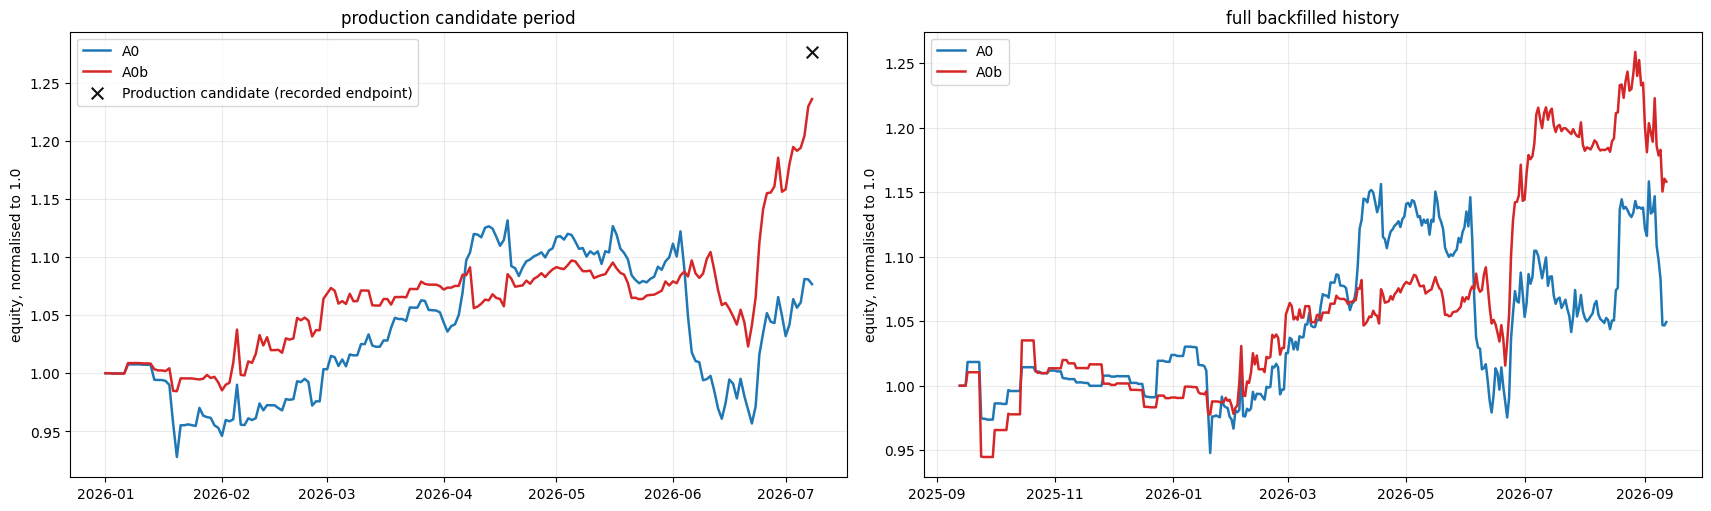

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5), constrained_layout=True)
for axis, (period_name, (start, end)) in zip(axes, PERIODS.items()):
    for variant, colour in (("A0", "#1f77b4"), ("A0b", "#d62728")):
        curve = curves[(variant, period_name)]
        axis.plot(curve.date, curve.equity / curve.equity.iloc[0], label=variant, color=colour, linewidth=1.8)
    if period_name == "production_candidate_period":
        axis.scatter(
            [end], [191446.1458 / 150000], color="#111111", marker="x", s=70,
            label="Production candidate (recorded endpoint)", zorder=5,
        )
    axis.set_title(period_name.replace("_", " "))
    axis.set_ylabel("equity, normalised to 1.0")
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()


## Vault inclusion and exclusion

The membership table is built from every address present in either comparison window. `A0` includes an address when it is present in the independent panel. `A0b` additionally requires the production-style allowlist and the blacklist check. `selected_*` records whether the simulator actually allocated a non-zero target at least once in the production candidate period. The complete table is saved as a CSV so excluded addresses can be audited without truncation.

In [4]:
all_addresses = sorted(set(features.address))
name_map = metadata.drop_duplicates("address").set_index("address")
production_selected = {}
for variant in ("A0", "A0b"):
    pool = pool_ledgers[(variant, "production_candidate_period")]
    production_selected[variant] = set(pool.loc[pool.target_dollars.gt(0), "address"]) if not pool.empty else set()

membership = pd.DataFrame({"address": all_addresses})
membership["name"] = membership.address.map(name_map["name"])
membership["vault_slug"] = membership.address.map(name_map["vault_slug"])
membership["in_production_style_allowlist"] = membership.address.isin(production_style_allowlist)
membership["manual_blacklist"] = membership.address.isin(manual_blacklist)
membership["in_A0_panel"] = True
membership["in_A0b_panel"] = membership.in_production_style_allowlist & ~membership.manual_blacklist
membership["selected_A0_production_period"] = membership.address.isin(production_selected["A0"])
membership["selected_A0b_production_period"] = membership.address.isin(production_selected["A0b"])
membership["status"] = np.select(
    [membership.manual_blacklist, ~membership.in_production_style_allowlist, membership.selected_A0b_production_period, membership.selected_A0_production_period],
    ["excluded: manual blacklist", "excluded: outside production-style allowlist", "included and selected by A0b", "included in A0 but not selected by A0b"],
    default="included in A0 panel; not selected",
)
membership.to_csv(ARTIFACTS / "a0-a0b-vault-membership.csv", index=False)
membership_summary = membership.groupby("status", dropna=False).size().rename("vaults").reset_index()
display(membership_summary)
display(membership.sort_values(["status", "name", "address"])[["address", "name", "in_production_style_allowlist", "manual_blacklist", "selected_A0_production_period", "selected_A0b_production_period", "status"]])


,status,vaults
0,excluded: manual blacklist,1
1,excluded: outside production-style allowlist,194
2,included and selected by A0b,28
3,included in A0 panel; not selected,309


,address,name,in_production_style_allowlist,manual_blacklist,selected_A0_production_period,selected_A0b_production_period,status
188,0x5290ab34acb59cfe1371baa5782eba14433d308f,Scared Money,False,True,True,False,excluded: manual blacklist
475,0xdeb0fe5ba4902c65eaa21ab9dca53e04c09d6f52,$$$ printing,False,False,False,False,excluded: outside production-style allowlist
484,0xe528531fc82ab104397fe06c550f0bb00720e0ab,$100K Target,False,False,False,False,excluded: outside production-style allowlist
478,0xe3c97b18216f58af4b9c1347d0ee010c42e6a85d,$REKTOBER,False,False,False,False,excluded: outside production-style allowlist
197,0x5661a070eb13c7c55ac3210b2447d4bea426cbf5,+convexity,False,False,False,False,excluded: outside production-style allowlist
...,...,...,...,...,...,...,...
448,0xd205094dacbede469596d3e27de2bbf53504bbcf,NaN,True,False,False,False,included in A0 panel; not selected
449,0xd21fdb5f5e167c5a05aa6a544fa9afc313bb2454,NaN,True,False,False,False,included in A0 panel; not selected
472,0xdb70d313a7e1fc142df85c09acd494cebc873583,NaN,True,False,False,False,included in A0 panel; not selected
501,0xefd0b10a0f4df0721da98f2505d270ca0e75b46e,NaN,True,False,False,False,included in A0 panel; not selected


## Stability and concentration checks

The comparison is interpreted as a universe reconciliation, not as a fresh parameter search. The checks below identify whether a close endpoint is driven by a single allocation and report the largest target-dollar contributors. A0b is only considered close to production if the production-period endpoint, drawdown and Sharpe move in the same direction without a single-vault explanation.

In [5]:
concentration_rows = []
for variant in ("A0", "A0b"):
    pool = pool_ledgers[(variant, "production_candidate_period")]
    selected = pool[pool.target_dollars.gt(0)].copy()
    totals = selected.groupby("address").target_dollars.sum().sort_values(ascending=False)
    total = totals.sum()
    concentration_rows.append({
        "variant": variant,
        "selected_vaults": int(len(totals)),
        "top_vault": totals.index[0] if len(totals) else None,
        "top_vault_target_dollars": float(totals.iloc[0]) if len(totals) else np.nan,
        "top_vault_share_of_target": float(totals.iloc[0] / total) if total else np.nan,
        "top5_share_of_target": float(totals.head(5).sum() / total) if total else np.nan,
    })
concentration = pd.DataFrame(concentration_rows)
concentration.to_csv(ARTIFACTS / "a0-a0b-concentration.csv", index=False)
display(concentration.round(4))
for variant in ("A0", "A0b"):
    print(f"{variant} largest contributors")
    display(
        pool_ledgers[(variant, "production_candidate_period")]
        .query("target_dollars > 0")
        .groupby("address", as_index=False)["target_dollars"].sum()
        .sort_values("target_dollars", ascending=False)
        .head(10)
        .merge(metadata, on="address", how="left")
    )


,variant,selected_vaults,top_vault,top_vault_target_dollars,top_vault_share_of_target,top5_share_of_target
0,A0,33,0x4dec0a851849056e259128464ef28ce78afa27f6,2.731367e+06,0.1892,0.5333
1,A0b,28,0x4dec0a851849056e259128464ef28ce78afa27f6,2.426528e+06,0.1652,0.6203


A0 largest contributors


,address,target_dollars,name,vault_slug
0,0x4dec0a851849056e259128464ef28ce78afa27f6,2.731367e+06,pmalt,pmalt
1,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,1.585218e+06,Citadel,citadel
2,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,1.378475e+06,Realist Capital,realist-capital
3,0xd2f03635901956b950737bbf02463dfad9f2e9e1,1.090558e+06,Gucky_1coin_1dot5x,gucky-1coin-1dot5x
4,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f,9.141729e+05,Goon Edging,goon-edging
5,0x65aee08c9235025355ac6c5ad020fb167ecef4fe,8.981932e+05,BULBUL2DAO,bulbul2dao
6,0xac26cf5f3c46b5e102048c65b977d2551b72a9c7,8.916479e+05,Long HYPE & BTC | Short Garbage,long-hype-btc-short-garbage
7,0xca230e816bdb34a46960c2f978a30a563d1ae9e0,8.808931e+05,Hyperrr,hyperrr
8,0xa844d7ac9fa3424c4fd38a25baa23e460ec3e802,6.552366e+05,69 Jump Street,69-jump-street
9,0xba939edf38c0ae0cc689c98b492e0535f43e4550,5.446437e+05,22Cap,22cap


A0b largest contributors


,address,target_dollars,name,vault_slug
0,0x4dec0a851849056e259128464ef28ce78afa27f6,2.426528e+06,pmalt,pmalt
1,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,1.988406e+06,Citadel,citadel
2,0xba939edf38c0ae0cc689c98b492e0535f43e4550,1.797273e+06,22Cap,22cap
3,0xd2f03635901956b950737bbf02463dfad9f2e9e1,1.555357e+06,Gucky_1coin_1dot5x,gucky-1coin-1dot5x
4,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,1.345827e+06,Realist Capital,realist-capital
5,0xa844d7ac9fa3424c4fd38a25baa23e460ec3e802,1.255004e+06,69 Jump Street,69-jump-street
6,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f,9.604324e+05,Goon Edging,goon-edging
7,0x07fd993f0fa3a185f7207adccd29f7a87404689d,5.768124e+05,[ Systemic Strategies ] L/S Grids,systemic-strategies-l-s-grids
8,0xbbf7d7a9d0eaeab4115f022a6863450296112422,3.911136e+05,Satori Quantum HF Vault,satori-quantum-hf-vault
9,0x82eba5dc675279cb5967952f0c4b5184505eb17c,3.831984e+05,JizzJazz,jizzjazz


In [6]:
manifest = {
    "variant": "A0b",
    "source_notebook": "07-stable-profit-validation.ipynb",
    "universe_cache": str(UNIVERSE_CACHE),
    "universe_cache_mtime": pd.Timestamp(UNIVERSE_CACHE.stat().st_mtime, unit="s").isoformat(),
    "production_allowlist_count": len(production_allowlist),
    "manual_blacklist": sorted(manual_blacklist),
    "a0_definition": "all independent feature-panel addresses in the period",
    "a0b_definition": "A0 with current production-style allowlist and manual blacklist",
    "periods": {name: [str(start.date()), str(end.date())] for name, (start, end) in PERIODS.items()},
    "forward_fill": True,
    "max_positions": 6,
    "production_curve_note": "Archived production series was not retained; endpoint-only marker used.",
}
(ARTIFACTS / "run-manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))


{
  "variant": "A0b",
  "source_notebook": "07-stable-profit-validation.ipynb",
  "universe_cache": "/Users/moo/.cache/indicators/vault-universe-tvl7500-top9999-age0.0-sort1Y-curbbf10d84.json",
  "universe_cache_mtime": "2026-09-09T09:33:40.880754471",
  "production_allowlist_count": 339,
  "manual_blacklist": [
    "0x5290ab34acb59cfe1371baa5782eba14433d308f"
  ],
  "a0_definition": "all independent feature-panel addresses in the period",
  "a0b_definition": "A0 with current production-style allowlist and manual blacklist",
  "periods": {
    "production_candidate_period": [
      "2026-01-01",
      "2026-07-08"
    ],
    "full_backfilled_history": [
      "2025-09-13",
      "2026-09-12"
    ]
  },
  "forward_fill": true,
  "max_positions": 6,
  "production_curve_note": "Archived production series was not retained; endpoint-only marker used."
}
